# Huggingface Transformer Demo

In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. Setup: Load Model and Tokenizer

In [2]:
# Load Model and Tokenizer
model_name = "gpt2" # You can swap this with "gpt2-medium" or "meta-llama/Llama-2-7b-hf"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# Set padding token to eos_token as GPT-2 doesn't have a default pad token
tokenizer.pad_token = tokenizer.eos_token


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

# Custom Function to Generate Text Using an LLM

In [3]:
def generate_text(prompt, max_length=50, temperature=1.0, top_k=50, top_p=1.0):
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_length,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=True if temperature != 1.0 or top_p < 1.0 else False,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# 1. Tokenization

In [4]:
text = "Tokenization is magic!"
tokens = tokenizer.tokenize(text)
ids = tokenizer.convert_tokens_to_ids(tokens)
print(f"Text: {text}")
print(f"Tokens: {tokens}")
print(f"IDs: {ids}\n")


--- 1. Tokenization ---
Text: Tokenization is magic!
Tokens: ['Token', 'ization', 'Ġis', 'Ġmagic', '!']
IDs: [30642, 1634, 318, 5536, 0]



# 2. In-Context Learning (ICL)

### In-Context Learning (Sentiment Analysis)

## ZERO-SHOT


In [19]:
# Target Input: The specific review we want to classify
target_review = 'Review: "The wait time was long, but the food was worth it."\nSentiment:'

# A. Zero-Shot: Direct prompt, no examples.
zero_shot_prompt = f"Classify the sentiment as Positive or Negative.\n{target_review}"

print("--- ZERO-SHOT ---")
print(generate_text(zero_shot_prompt, max_length=10))

--- ZERO-SHOT ---
Classify the sentiment as Positive or Negative.
Review: "The wait time was long, but the food was worth it."
Sentiment: "I'm glad I got to eat here.


The above didn't do the sentiment classification. The LLM solves a sentence completion task.

# ONE-SHOT

In [17]:
# B. One-Shot: Providing one example to establish the "Review: [Text] \n Sentiment: [Label]" pattern.
one_shot_prompt = f"""Review: "I absolutely loved the cinematography!"
Sentiment: Positive

{target_review}"""

print("\n--- ONE-SHOT ---")
print(generate_text(one_shot_prompt, max_length=2))


--- ONE-SHOT ---
Review: "I absolutely loved the cinematography!"
Sentiment: Positive

Review: "The wait time was long, but the food was worth it."
Sentiment: Negative



# FEW-SHOT

In [20]:
# C. Few-Shot: Providing multiple examples to show the variety of possible labels.
few_shot_prompt = f"""Review: "The movie was a complete disaster."
Sentiment: Negative

Review: "It was an okay experience, nothing special."
Sentiment: Neutral

Review: "The best meal I've had in years!"
Sentiment: Positive

{target_review}"""

print("\n--- FEW-SHOT ---")
print(generate_text(few_shot_prompt, max_length=2))


--- FEW-SHOT ---
Review: "The movie was a complete disaster."
Sentiment: Negative

Review: "It was an okay experience, nothing special."
Sentiment: Neutral

Review: "The best meal I've had in years!"
Sentiment: Positive

Review: "The wait time was long, but the food was worth it."
Sentiment: Negative



# 3. Text Summarization

In [24]:
long_text = """The hydrogen fuel cell is a device that converts chemical energy into electricity.
It uses hydrogen gas and oxygen from the air. The only byproduct is water, making it a
very clean energy source for cars and homes."""

summ_prompt = f"Summarize the following text: {long_text}"

print(generate_text(summ_prompt, max_length=15))


Summarize the following text: The hydrogen fuel cell is a device that converts chemical energy into electricity. 
It uses hydrogen gas and oxygen from the air. The only byproduct is water, making it a 
very clean energy source for cars and homes. 
The hydrogen fuel cell is a device that converts chemical energy into electricity


# 4. Temperature

## Low temperature = focused/deterministic

In [26]:
temp_prompt = "The future of AI is "

# Low temperature = focused/deterministic;
print(f"Low Temp (0.2): {generate_text(temp_prompt, temperature=0.2)}")


Low Temp (0.2): The future of AI is  a matter of debate. There are many reasons for this, but the most obvious is that the technology is evolving rapidly. The AI revolution is already happening, and it will continue to evolve. We are already seeing the emergence of new technologies that will


## High temperature = creative/random

In [27]:
# High temperature = creative/random
print(f"High Temp (1.5): {generate_text(temp_prompt, temperature=1.5)}")

High Temp (1.5): The future of AI is  not very clear... it doesn't really seem far from there." -- Andy Koojima, Artificial Intelligence Analyst for Intel (IBM) "Even assuming that the technology goes anywhere I'm still in some ways amazed for how far advances


## What does **temperature=1.0** signify?

A temperature of 1.0 signifies **Neutral Scaling**.
It means the model uses its calculated probabilities exactly as they are, without stretching or compressing them.
It is the the default.
In almost every major LLM framework (Hugging Face, OpenAI, Anthropic), 1.0 is the standard default value.

The Math: If $T = 1.0$, the probability $P_i$ for a word $i$ is calculated as:

$$P_i = \frac{\exp(f_i / 1.0)}{\sum \exp(f_j / 1.0)}$$

Since dividing by 1 doesn't change the input, the model's internal confidence remains "natural."


## How Temperature Changes the Output

Think of Temperature as a "**Confidence Filter**"

It adjusts the gap between the most likely word and the less likely words.



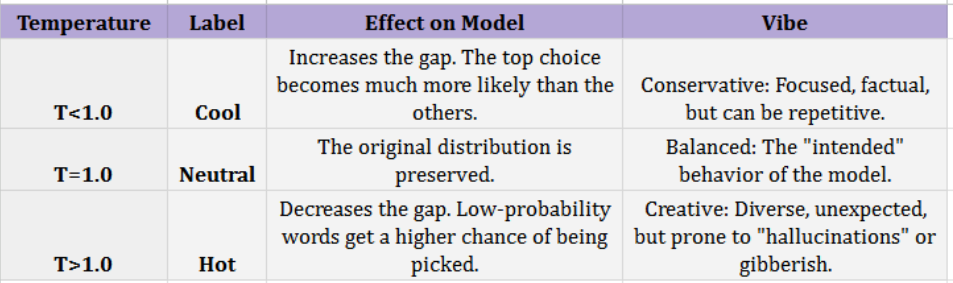

# 5. Max Output Length


In [8]:
print(f"Short (10 tokens): {generate_text('Once upon a time', max_length=10)}")

print(f"Long (50 tokens): {generate_text('Once upon a time', max_length=50)}")



--- 5. Max Length Testing ---
Short (10 tokens): Once upon a time, the world was a place of great beauty and
Long (50 tokens): Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a place of great danger


# 6. Top-K and Top-P

# Using the existing generate_text method (by default, sampling is turned-off)

In [9]:
# Top-K: Limits vocabulary to top K most likely next words
# Top-P: Limits vocabulary to a cumulative probability (e.g., top 95%)

sampling_prompt = "In a galaxy far, far away"

print(f"Top-K (k=10): {generate_text(sampling_prompt, top_k=10)}")

print(f"Top-P (p=0.9): {generate_text(sampling_prompt, top_p=0.9)}")

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- 6. Top-K & Top-P Testing ---
Top-K (k=10): In a galaxy far, far away, the galaxy is a vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast, vast
Top-P (p=0.9): In a galaxy far, far away, with a little help from the universe's largest space craft. In the new video of the project, the Star Trek Space Show Star Trek: The New Frontier stars Voyager in their new space mission. They are joined by James Hurwitz from NBC's


# Update the generate_text method to incorporate sampling.

In the Hugging Face generate() method, there are two primary ways to pick the next word: Greedy Search and Sampling.

### 1. The Logic Breakdown

The code checks two conditions to decide if it should turn on "**Sampling**" mode:

**temperature != 1.0**: If you’ve changed the temperature (making the model more or less "creative"), you must sample.

**top_p < 1.0**: If you’ve restricted the word pool to a cumulative probability (Nucleus Sampling), you must sample.

If either is true, do_sample becomes True. Otherwise, it defaults to False.

### 2. Greedy Search (do_sample=False)

When this is false, the model is a perfectionist. It looks at the probability of every possible next word and only picks the one with the highest percentage.

Result: It is deterministic. If you run the prompt 100 times, you get the exact same answer 100 times.

The Flaw: As you saw in your "vast, vast, vast" example, small models like GPT-2 often get stuck in repetitive loops because the most "likely" word after "vast" is often "vast."

### 3. Sampling (do_sample=True)

When this is true, the model becomes a gambler. Instead of just picking the #1 word, it treats the probabilities like a giant spinning wheel. If "vast" has a 60% chance and "star" has a 5% chance, the model usually picks "vast," but sometimes it picks "star."

Result: The text sounds more human, varied, and creative.

The Flaw: If the temperature is too high, it might pick a word with 0.001% probability and start talking nonsense.


In [28]:
def generate_text(prompt, max_length=50, temperature=1.0, top_k=50, top_p=1.0):
    inputs = tokenizer(prompt, return_tensors="pt")

    # Force do_sample=True if we are experimenting with sampling parameters
    # Otherwise, the model defaults to Greedy Search and ignores top_k/top_p
    is_sampling = True if (temperature != 1.0 or top_k != 50 or top_p < 1.0) else False

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_length,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=is_sampling,
        pad_token_id=tokenizer.eos_token_id,
        no_repeat_ngram_size=2 # Prevents the "vast, vast, vast" repetition loop
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# --- EXPERIMENT 6: Top-K & Top-P Testing ---
sampling_prompt = "In a galaxy far, far away"

print("--- 6. Top-K & Top-P Testing ---")
# Explicitly set a non-default top_k to trigger sampling
print(f"Top-K (k=10): {generate_text(sampling_prompt, top_k=10, temperature=0.7)}")

# Explicitly set a top_p < 1.0 to trigger sampling
print(f"Top-P (p=0.9): {generate_text(sampling_prompt, top_p=0.9, temperature=0.7)}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- 6. Top-K & Top-P Testing ---
Top-K (k=10): In a galaxy far, far away, it's possible to see the universe. It's also possible for people to be able to do it. There's a lot of things that you can do without the help of the computer. But you still have to go through a process of getting
Top-P (p=0.9): In a galaxy far, far away, a single black hole is a blackhole. A black-hole is one that is in a constant state of inflation, as it's always doing. And it is constantly in an inflationary state. The black holes that are constantly inflationing are
